# 🌍 Carbon Emission Forecasting — Malaysia

**Author:** Ariff Azahari  
**Datasets:** `ghg_emissions.csv` · `air_pollution.csv`  
**Objective:** Forecast total GHG emissions and air pollutant concentrations for the next 5–10 years using multiple models.

---

## Pipeline Overview
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Stationarity Tests (ADF & KPSS)
4. Feature Engineering (Lag Features, Rolling Stats)
5. Model Training — Prophet + XGBoost + SARIMA
6. Model Evaluation (MAE, RMSE, MAPE)
7. Forecast Visualisation with Confidence Intervals

## 📦 0. Install & Import Dependencies

In [2]:
# Install required libraries (run once)
%pip install prophet xgboost statsmodels scikit-learn matplotlib seaborn pandas numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)

   ---------------------------------------- 0/5 [scikit-learn]
   ---------------------------------------- 0/5 [scikit-learn]
   ---------------------------------------- 0/5 [scikit-learn]
   ---------------------------------------- 0/5 [scikit-learn]
   -----------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import xgboost as xgb
from prophet import Prophet

# Plotting style
plt.style.use('dark_background')
sns.set_palette('muted')
ACCENT = '#4279a4'
ACCENT2 = '#ddd1ca'
FIG_W, FIG_H = 14, 5

print('✅ All libraries imported successfully')

Importing plotly failed. Interactive plots will not work.


✅ All libraries imported successfully


---
## 📂 1. Data Loading & Overview

In [25]:
# ── Load datasets ──────────────────────────────────────────────────────────────
ghg_raw = pd.read_csv('ghg_emissions.csv', parse_dates=['date'])
air_raw = pd.read_csv('air_pollution.csv', parse_dates=['date'])

print('GHG Emissions Dataset:')
print(ghg_raw.dtypes)
print(f'Shape: {ghg_raw.shape}  |  Date range: {ghg_raw.date.min().year} → {ghg_raw.date.max().year}')
print(f'Sources: {ghg_raw.source.unique().tolist()}')
print()
print('Air Pollution Dataset:')
print(air_raw.dtypes)
print(f'Shape: {air_raw.shape}  |  Date range: {air_raw.date.min()} → {air_raw.date.max()}')
print(f'Pollutants: {air_raw.pollutant.unique().tolist()}')

GHG Emissions Dataset:
date         datetime64[us]
source                  str
emissions           float64
dtype: object
Shape: (56, 3)  |  Date range: 2014 → 2021
Sources: ['total', 'net', 'energy', 'industrial_processes', 'agriculture', 'waste', 'lulucf']

Air Pollution Dataset:
date             datetime64[us]
pollutant                   str
concentration           float64
dtype: object
Shape: (432, 3)  |  Date range: 2017-01-01 00:00:00 → 2022-12-01 00:00:00
Pollutants: ['CO', 'NO2', 'O3', 'PM 10', 'PM 2.5', 'SO2']


In [26]:
# ── GHG: pivot to wide format ──────────────────────────────────────────────────
ghg = ghg_raw.pivot(index='date', columns='source', values='emissions').reset_index()
ghg.columns.name = None
ghg = ghg.sort_values('date').reset_index(drop=True)
print('GHG (wide):')
display(ghg)
print(f'\nMissing values per column:\n{ghg.isnull().sum()}')

GHG (wide):


,date,agriculture,energy,industrial_processes,lulucf,net,total,waste
0,2014-01-01,11095.67,255079.75,20235.40,-249952.54,64835.93,314788.47,28377.66
1,2015-01-01,10647.03,256850.16,22243.93,-244032.12,74492.91,318525.03,28783.91
2,2016-01-01,10711.36,253850.16,23746.04,-215375.05,98804.40,314179.45,26565.41
3,2017-01-01,11063.54,252710.49,24203.62,-243369.73,73193.32,316563.05,28585.40
4,2018-01-01,10690.29,255231.55,26697.07,-241264.08,79602.70,320866.78,28247.87
5,2019-01-01,9921.71,259326.11,32853.80,-214714.54,115643.68,330358.21,28256.59
6,2020-01-01,NaN,NaN,NaN,NaN,NaN,323378.81,NaN
7,2021-01-01,NaN,NaN,NaN,NaN,NaN,325705.28,NaN



Missing values per column:
date                    0
agriculture             2
energy                  2
industrial_processes    2
lulucf                  2
net                     2
total                   0
waste                   2
dtype: int64


In [27]:
# ── Air Pollution: pivot to wide format ───────────────────────────────────────
air = air_raw.pivot(index='date', columns='pollutant', values='concentration').reset_index()
air.columns.name = None
air = air.sort_values('date').reset_index(drop=True)

# Interpolate missing values (linear) — only PM 2.5 has a full year missing at start
air_numeric = air.drop(columns='date')
air_numeric = air_numeric.interpolate(method='linear', limit_direction='both')
air = pd.concat([air[['date']], air_numeric], axis=1)

print('Air Pollution (wide, interpolated):')
display(air.head(10))
print(f'\nMissing after interpolation:\n{air.isnull().sum()}')

Air Pollution (wide, interpolated):


,date,CO,NO2,O3,PM 10,PM 2.5,SO2
0,2017-01-01,0.561,0.007600,0.015000,38.000000,11.43,0.002300
1,2017-02-01,0.530,0.007100,0.018000,40.890000,11.43,0.002500
2,2017-03-01,0.589,0.008200,0.017000,42.310000,11.43,0.002800
3,2017-04-01,0.662,0.008700,0.015000,37.760000,11.43,0.002700
4,2017-05-01,0.680,0.008533,0.015333,34.943333,11.43,0.002267
5,2017-06-01,0.698,0.008367,0.015667,32.126667,11.43,0.001833
6,2017-07-01,0.716,0.008200,0.016000,29.310000,11.43,0.001400
7,2017-08-01,0.661,0.007800,0.016000,24.960000,11.43,0.001000
8,2017-09-01,0.682,0.007600,0.015000,23.410000,11.43,0.001100
9,2017-10-01,0.680,0.008200,0.017000,24.320000,11.43,0.001200



Missing after interpolation:
date      0
CO        0
NO2       0
O3        0
PM 10     0
PM 2.5    0
SO2       0
dtype: int64


---
## 📊 2. Exploratory Data Analysis (EDA)

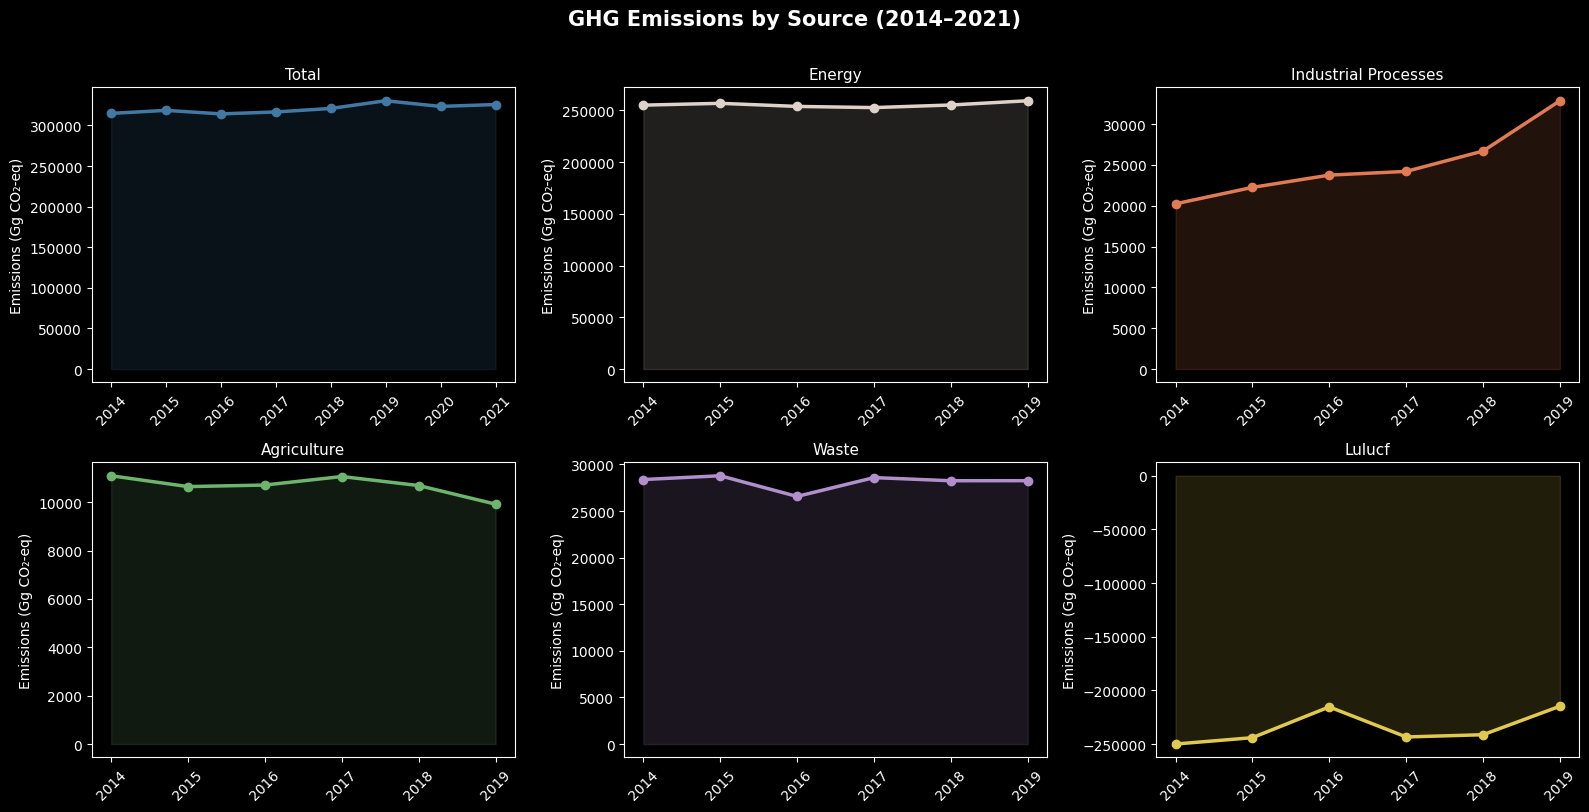

In [7]:
# ── GHG: All sources over time ─────────────────────────────────────────────────
sources_to_plot = ['total', 'energy', 'industrial_processes', 'agriculture', 'waste', 'lulucf']
colors = [ACCENT, ACCENT2, '#e07b54', '#6db56d', '#b08fcc', '#e0c94e']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('GHG Emissions by Source (2014–2021)', fontsize=15, fontweight='bold', y=1.01)

for ax, src, col in zip(axes.flatten(), sources_to_plot, colors):
    if src in ghg.columns:
        ax.plot(ghg['date'], ghg[src], marker='o', color=col, linewidth=2.5, markersize=6)
        ax.fill_between(ghg['date'], ghg[src], alpha=0.15, color=col)
        ax.set_title(src.replace('_', ' ').title(), fontsize=11)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('Emissions (Gg CO₂-eq)')

plt.tight_layout()
plt.show()

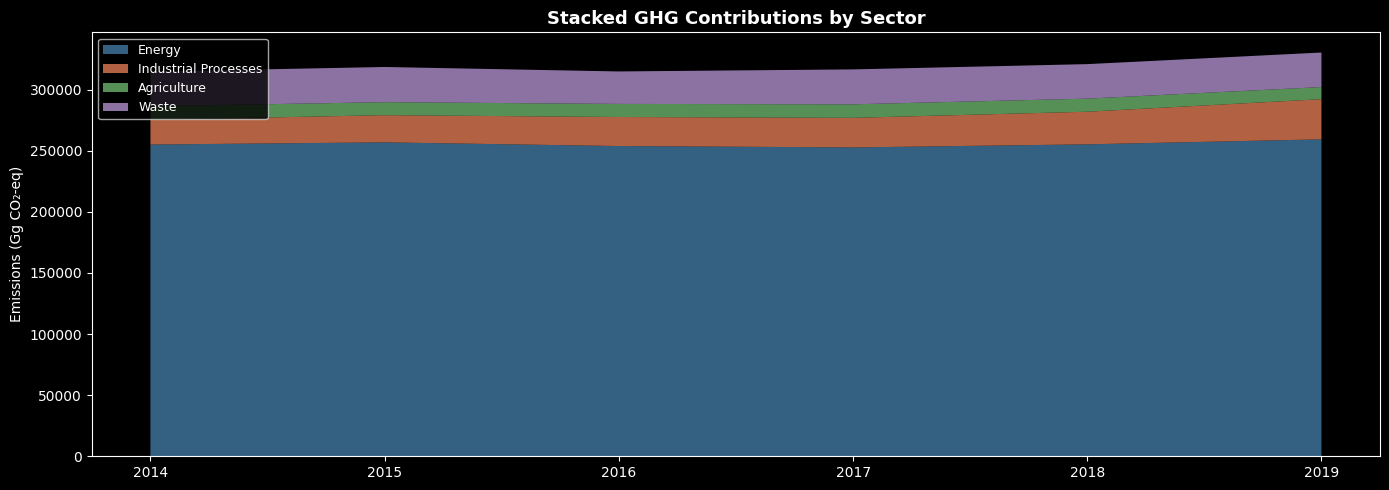

In [8]:
# ── GHG: Stacked area chart of contributors ────────────────────────────────────
contributors = ['energy', 'industrial_processes', 'agriculture', 'waste']
stacked_data = ghg[['date'] + contributors].dropna()

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.stackplot(
    stacked_data['date'],
    [stacked_data[c] for c in contributors],
    labels=[c.replace('_', ' ').title() for c in contributors],
    colors=['#4279a4', '#e07b54', '#6db56d', '#b08fcc'],
    alpha=0.8
)
ax.set_title('Stacked GHG Contributions by Sector', fontsize=13, fontweight='bold')
ax.set_ylabel('Emissions (Gg CO₂-eq)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

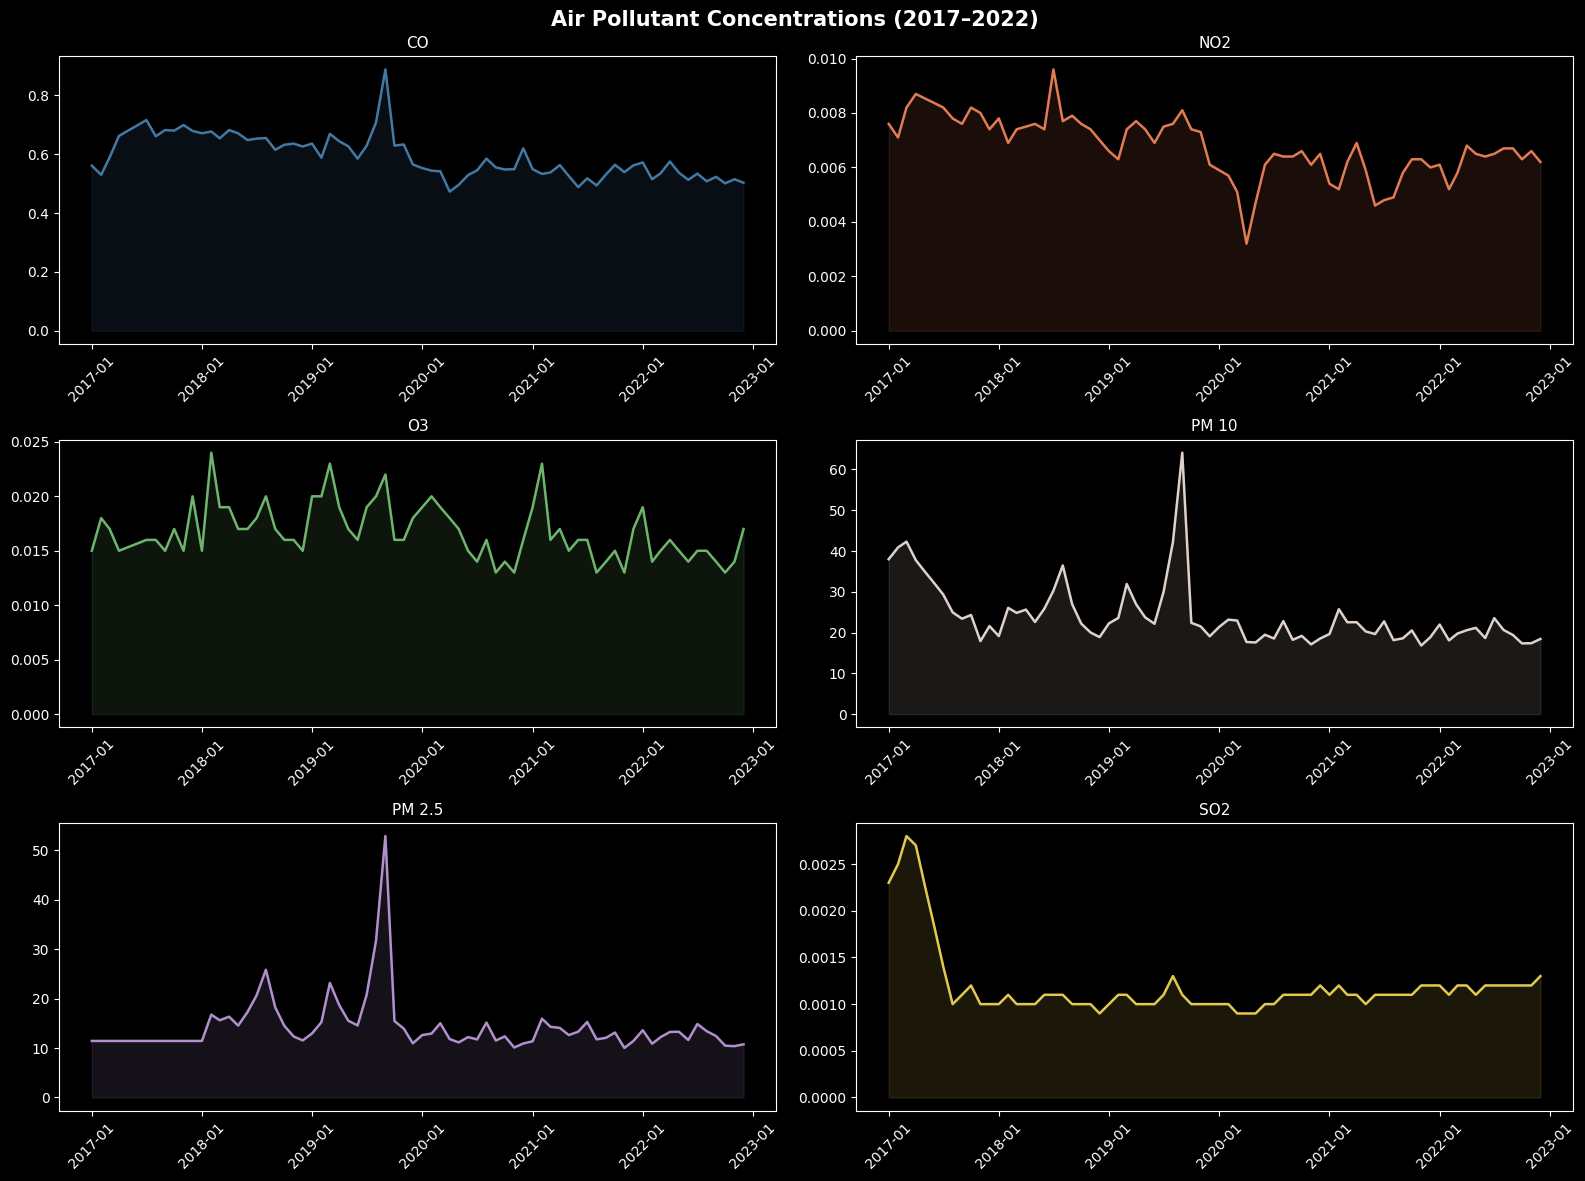

In [9]:
# ── Air Pollution: All pollutants over time ────────────────────────────────────
pollutants = [c for c in air.columns if c != 'date']
colors_air = ['#4279a4', '#e07b54', '#6db56d', '#ddd1ca', '#b08fcc', '#e0c94e']

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Air Pollutant Concentrations (2017–2022)', fontsize=15, fontweight='bold')

for ax, poll, col in zip(axes.flatten(), pollutants, colors_air):
    ax.plot(air['date'], air[poll], color=col, linewidth=1.8)
    ax.fill_between(air['date'], air[poll], alpha=0.12, color=col)
    ax.set_title(poll, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

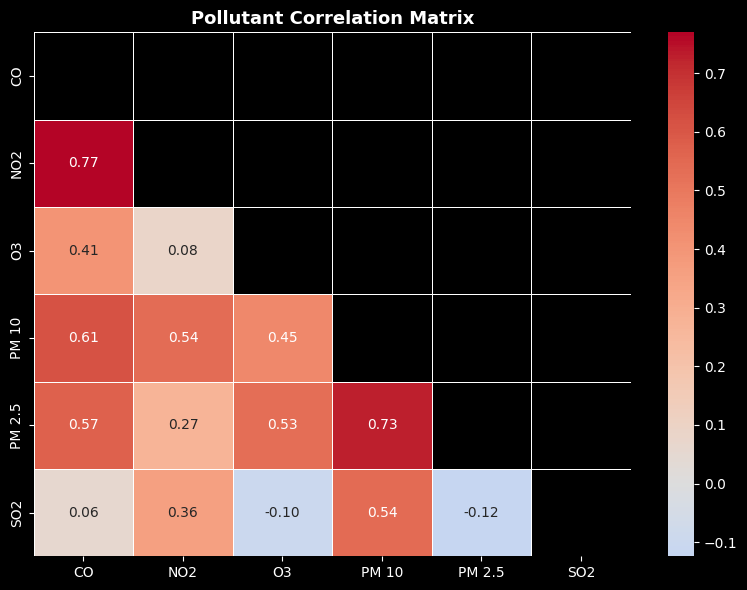

In [28]:
# ── Correlation heatmap: air pollutants ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = air[pollutants].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Pollutant Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧪 3. Stationarity Tests

In [29]:
def stationarity_report(series: pd.Series, name: str) -> dict:
    """Run ADF and KPSS tests; print a clean summary."""
    series = series.dropna()
    
    # ADF: H0 = unit root (non-stationary). Reject H0 → stationary
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag='AIC')
    
    # KPSS: H0 = stationary. Reject H0 → non-stationary
    kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='c', nlags='auto')
    
    adf_result = 'Stationary ✅' if adf_p < 0.05 else 'Non-stationary ⚠️'
    kpss_result = 'Stationary ✅' if kpss_p > 0.05 else 'Non-stationary ⚠️'
    
    print(f'\n── {name} ─────────────────────────────────')
    print(f'  ADF  stat={adf_stat:.3f}  p={adf_p:.4f}  → {adf_result}')
    print(f'  KPSS stat={kpss_stat:.3f}  p={kpss_p:.4f}  → {kpss_result}')
    
    return {'name': name, 'adf_p': adf_p, 'kpss_p': kpss_p,
            'adf_stationary': adf_p < 0.05, 'kpss_stationary': kpss_p > 0.05}

# Test GHG total
ghg_total = ghg[['date', 'total']].dropna().set_index('date')['total']
stationarity_report(ghg_total, 'GHG Total Emissions')

# Test first-differenced GHG total
stationarity_report(ghg_total.diff().dropna(), 'GHG Total — 1st Difference')

# Test CO (monthly)
co_series = air.set_index('date')['CO']
stationarity_report(co_series, 'Air Pollution — CO')


── GHG Total Emissions ─────────────────────────────────
  ADF  stat=-1.314  p=0.6227  → Non-stationary ⚠️
  KPSS stat=0.404  p=0.0755  → Stationary ✅

── GHG Total — 1st Difference ─────────────────────────────────
  ADF  stat=-3.002  p=0.0347  → Stationary ✅
  KPSS stat=0.350  p=0.0985  → Stationary ✅

── Air Pollution — CO ─────────────────────────────────
  ADF  stat=-2.279  p=0.1789  → Non-stationary ⚠️
  KPSS stat=1.066  p=0.0100  → Non-stationary ⚠️


C:\Users\ariff\AppData\Local\Temp\ipykernel_19748\2702074968.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='c', nlags='auto')


{'name': 'Air Pollution — CO',
 'adf_p': np.float64(0.17894195714280214),
 'kpss_p': np.float64(0.01),
 'adf_stationary': np.False_,
 'kpss_stationary': np.False_}

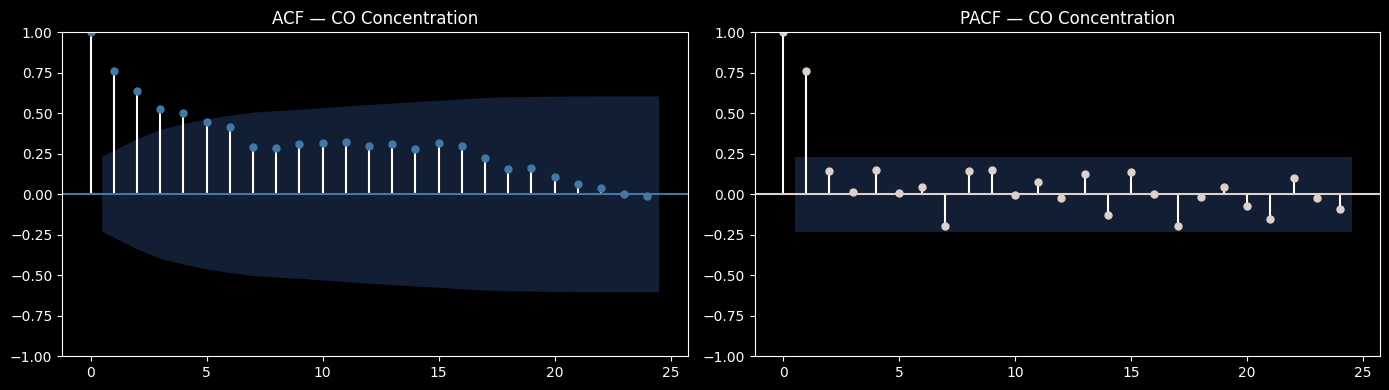

In [12]:
# ── ACF / PACF for CO monthly ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(co_series.dropna(), ax=axes[0], lags=24, color=ACCENT)
plot_pacf(co_series.dropna(), ax=axes[1], lags=24, color=ACCENT2)
axes[0].set_title('ACF — CO Concentration')
axes[1].set_title('PACF — CO Concentration')
plt.tight_layout()
plt.show()

---
## 🛠️ 4. Feature Engineering

In [34]:
def make_lag_features(df: pd.DataFrame, target_col: str, lags: list, rolling_windows: list, calendar_features: bool = True) -> pd.DataFrame:
    """Build lag and rolling-window features for XGBoost."""
    df = df.copy()
    
    # Lag features
    for lag in lags:
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    
    # Rolling statistics
    for w in rolling_windows:
        df[f'roll_mean_{w}'] = df[target_col].shift(1).rolling(w).mean()
        df[f'roll_std_{w}']  = df[target_col].shift(1).rolling(w).std()
    
    # Calendar features - only for sub-annual (monthly) data
    if calendar_features and hasattr(df.index, 'month'):
        df['month'] = df.index.month
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Year feature (trend proxy)
    df['year'] = df.index.year
    
    return df.dropna()


# ── GHG total features (annual data) ─────────────────────────────────────────
ghg_feat = ghg[['date', 'total']].dropna().set_index('date')
ghg_feat = make_lag_features(ghg_feat, 'total', lags=[1, 2], rolling_windows=[2, 3], calendar_features=False)
print('GHG feature matrix:')
display(ghg_feat)

# ── CO monthly features ───────────────────────────────────────────────────────
co_feat = air[['date', 'CO']].set_index('date')
co_feat = make_lag_features(co_feat, 'CO', lags=[1, 2, 3, 12], rolling_windows=[3, 6])
print('\nCO feature matrix (first 5 rows):')
display(co_feat.head())

GHG feature matrix:


,total,lag_1,lag_2,roll_mean_2,roll_std_2,roll_mean_3,roll_std_3,year
date,,,,,,,,
2017-01-01,316563.05,314179.45,318525.03,316352.240,3072.789086,315830.983333,2352.900746,2017
2018-01-01,320866.78,316563.05,314179.45,315371.250,1685.459724,316422.510000,2176.196223,2018
2019-01-01,330358.21,320866.78,316563.05,318714.915,3043.196667,317203.093333,3389.297454,2019
2020-01-01,323378.81,330358.21,320866.78,325612.495,6711.454516,322596.013333,7058.278529,2020
2021-01-01,325705.28,323378.81,330358.21,326868.510,4935.181069,324867.933333,4917.817309,2021



CO feature matrix (first 5 rows):


,CO,lag_1,lag_2,lag_3,lag_12,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,month,month_sin,month_cos,year
date,,,,,,,,,,,,,
2018-01-01,0.671,0.679,0.699,0.680,0.561,0.686000,0.011269,0.686167,0.018946,1,0.500000,8.660254e-01,2018
2018-02-01,0.677,0.671,0.679,0.699,0.530,0.683000,0.014422,0.678667,0.012628,2,0.866025,5.000000e-01,2018
2018-03-01,0.654,0.677,0.671,0.679,0.589,0.675667,0.004163,0.681333,0.009438,3,1.000000,6.123234e-17,2018
2018-04-01,0.682,0.654,0.677,0.671,0.662,0.667333,0.011930,0.676667,0.014569,4,0.866025,-5.000000e-01,2018
2018-05-01,0.671,0.682,0.654,0.677,0.680,0.671000,0.014933,0.677000,0.014683,5,0.500000,-8.660254e-01,2018


---
## 🤖 5. Model Training

### 5A. Prophet — GHG Total (Annual Forecast: 5–10 years)
Prophet handles small annual datasets well by fitting trend + uncertainty intervals without overfitting.

In [31]:
# ── Prepare data for Prophet ──────────────────────────────────────────────────
prophet_df = ghg[['date', 'total']].dropna().rename(columns={'date': 'ds', 'total': 'y'})

# Prophet model
m_prophet = Prophet(
    changepoint_prior_scale=0.2,    # allows moderate trend flexibility
    yearly_seasonality=False,       # annual data — no sub-year seasonality
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.90,            # 90% confidence interval
    n_changepoints=3,               # small dataset — limit changepoints
)

m_prophet.fit(prophet_df)

# Forecast: 10 years ahead (annual frequency)
future = m_prophet.make_future_dataframe(periods=10, freq='YS')
forecast_prophet = m_prophet.predict(future)

print('Prophet forecast (last 10 rows):')
display(forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

17:46:23 - cmdstanpy - INFO - Chain [1] start processing
17:46:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast (last 10 rows):


,ds,yhat,yhat_lower,yhat_upper
8,2022-01-01,322854.847132,318651.336031,327176.197989
9,2023-01-01,321205.788326,310167.613278,332756.570274
10,2024-01-01,319556.729520,298538.376854,339669.819201
11,2025-01-01,317903.152744,284921.715945,348590.655332
12,2026-01-01,316254.093938,270568.513917,362276.333932
13,2027-01-01,314605.035131,255429.257778,371716.774268
14,2028-01-01,312955.976325,237863.005164,386524.510945
15,2029-01-01,311302.399550,218390.843885,401247.373843
16,2030-01-01,309653.340743,200490.213485,412183.686130
17,2031-01-01,308004.281937,180497.368003,428777.299908


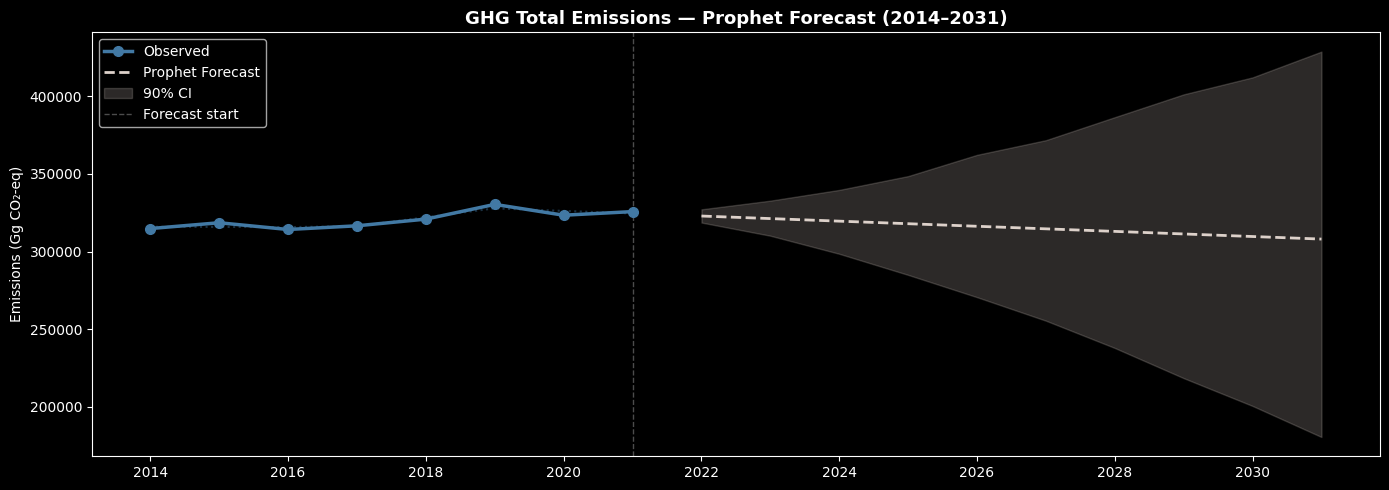

In [32]:
# ── Plot Prophet forecast ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

# Historical
ax.plot(prophet_df['ds'], prophet_df['y'], 'o-', color=ACCENT, linewidth=2.5,
        markersize=7, label='Observed', zorder=5)

# Forecast
fcast = forecast_prophet[forecast_prophet['ds'] > prophet_df['ds'].max()]
ax.plot(fcast['ds'], fcast['yhat'], '--', color=ACCENT2, linewidth=2, label='Prophet Forecast')
ax.fill_between(fcast['ds'], fcast['yhat_lower'], fcast['yhat_upper'],
                alpha=0.2, color=ACCENT2, label='90% CI')

# In-sample fitted
in_sample = forecast_prophet[forecast_prophet['ds'] <= prophet_df['ds'].max()]
ax.plot(in_sample['ds'], in_sample['yhat'], color=ACCENT, linewidth=1.5, alpha=0.4, linestyle=':')

ax.axvline(prophet_df['ds'].max(), color='white', linestyle='--', alpha=0.3, lw=1, label='Forecast start')
ax.set_title('GHG Total Emissions — Prophet Forecast (2014–2031)', fontsize=13, fontweight='bold')
ax.set_ylabel('Emissions (Gg CO₂-eq)')
ax.legend()
plt.tight_layout()
plt.show()

### 5B. XGBoost — GHG Total (Annual)

> Note: With only 8 annual data points, XGBoost is used in a recursive multi-step fashion for educational comparison. Prophet is more reliable for this size.

In [35]:
# ── XGBoost — GHG Total ───────────────────────────────────────────────────────
feature_cols = [c for c in ghg_feat.columns if c != 'total']
X = ghg_feat[feature_cols].values
y = ghg_feat['total'].values

# Train on all data (no test split — dataset too small)
# Use cross-validated parameters
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X, y)

# Recursive multi-step forecasting
def xgb_recursive_forecast(model, history: pd.Series, n_steps: int, lags: list, windows: list) -> list:
    """Recursively forecast n_steps ahead using XGBoost."""
    hist = list(history.values)
    last_year = history.index.year[-1]
    forecasts = []

    for step in range(n_steps):
        row = []
        for lag in lags:
            row.append(hist[-lag] if len(hist) >= lag else np.nan)
        for w in windows:
            row.append(np.mean(hist[-w:]))
            row.append(np.std(hist[-w:]))
        row.append(last_year + step + 1)  # year feature
        pred = model.predict(np.array(row).reshape(1, -1))[0]
        forecasts.append(pred)
        hist.append(pred)

    return forecasts

ghg_history = ghg[['date','total']].dropna().set_index('date')['total']
xgb_preds = xgb_recursive_forecast(xgb_model, ghg_history, n_steps=10, lags=[1,2], windows=[2,3])
xgb_years = pd.date_range(start='2022', periods=10, freq='YS')

print('XGBoost Forecast (2022–2031):')
for yr, val in zip(xgb_years, xgb_preds):
    print(f'  {yr.year}: {val:,.2f} Gg CO₂-eq')

XGBoost Forecast (2022–2031):
  2022: 325,646.31 Gg CO₂-eq
  2023: 325,218.00 Gg CO₂-eq
  2024: 325,646.31 Gg CO₂-eq
  2025: 325,646.31 Gg CO₂-eq
  2026: 325,218.00 Gg CO₂-eq
  2027: 325,646.31 Gg CO₂-eq
  2028: 325,646.31 Gg CO₂-eq
  2029: 325,218.00 Gg CO₂-eq
  2030: 325,646.31 Gg CO₂-eq
  2031: 325,646.31 Gg CO₂-eq


### 5C. XGBoost — CO Monthly Forecast (Air Pollution)

In [36]:
# ── XGBoost — Monthly CO ──────────────────────────────────────────────────────
co_feature_cols = [c for c in co_feat.columns if c != 'CO']
X_co = co_feat[co_feature_cols].values
y_co = co_feat['CO'].values

# Train / Test split (last 12 months as test)
SPLIT = -12
X_train_co, X_test_co = X_co[:SPLIT], X_co[SPLIT:]
y_train_co, y_test_co = y_co[:SPLIT], y_co[SPLIT:]

xgb_co = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_co.fit(X_train_co, y_train_co, eval_set=[(X_test_co, y_test_co)], verbose=False)

y_pred_co = xgb_co.predict(X_test_co)
test_dates_co = co_feat.index[SPLIT:]

print('CO Test Set Metrics:')
print(f'  MAE  = {mean_absolute_error(y_test_co, y_pred_co):.4f}')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_test_co, y_pred_co)):.4f}')
print(f'  MAPE = {np.mean(np.abs((y_test_co - y_pred_co) / y_test_co)) * 100:.2f}%')

CO Test Set Metrics:
  MAE  = 0.0257
  RMSE = 0.0309
  MAPE = 4.92%


### 5D. Prophet — CO Monthly Forecast

In [37]:
# ── Prophet — Monthly CO ──────────────────────────────────────────────────────
co_prophet_df = air[['date','CO']].rename(columns={'date':'ds','CO':'y'})

m_co = Prophet(
    changepoint_prior_scale=0.05,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.90,
    seasonality_mode='multiplicative'
)
m_co.fit(co_prophet_df)

# Forecast 60 months (5 years)
future_co = m_co.make_future_dataframe(periods=60, freq='MS')
forecast_co = m_co.predict(future_co)

print('Prophet CO forecast (last 12 rows):')
display(forecast_co[['ds','yhat','yhat_lower','yhat_upper']].tail(12))

17:49:49 - cmdstanpy - INFO - Chain [1] start processing
17:49:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet CO forecast (last 12 rows):


,ds,yhat,yhat_lower,yhat_upper
120,2027-01-01,0.358693,0.284660,0.431112
121,2027-02-01,0.339957,0.265648,0.413952
122,2027-03-01,0.365390,0.297047,0.438087
123,2027-04-01,0.373763,0.299115,0.446299
124,2027-05-01,0.350552,0.279882,0.422541
125,2027-06-01,0.319797,0.240791,0.389337
126,2027-07-01,0.337970,0.271471,0.409966
127,2027-08-01,0.358319,0.288174,0.426665
128,2027-09-01,0.423232,0.347891,0.490263
129,2027-10-01,0.339753,0.270192,0.411347


---
## 📏 6. Model Evaluation

In [38]:
def eval_metrics(y_true, y_pred, model_name: str) -> dict:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'\n── {model_name} ─────────────────────────────────')
    print(f'  MAE  = {mae:.4f}')
    print(f'  RMSE = {rmse:.4f}')
    print(f'  MAPE = {mape:.2f}%')
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

results = []

# ── GHG Prophet: in-sample evaluation ─────────────────────────────────────────
in_sample_pred = forecast_prophet[forecast_prophet['ds'].isin(prophet_df['ds'])]['yhat'].values
results.append(eval_metrics(prophet_df['y'].values, in_sample_pred, 'Prophet — GHG Total (in-sample)'))

# ── CO XGBoost: test set ───────────────────────────────────────────────────────
results.append(eval_metrics(y_test_co, y_pred_co, 'XGBoost — CO Monthly (test set)'))

# ── CO Prophet: test set ───────────────────────────────────────────────────────
prophet_test = forecast_co[forecast_co['ds'].isin(co_prophet_df['ds'].iloc[SPLIT:])]['yhat'].values
results.append(eval_metrics(co_prophet_df['y'].iloc[SPLIT:].values, prophet_test, 'Prophet — CO Monthly (test set)'))

print('\n=== Summary ===')
display(pd.DataFrame(results).set_index('Model').round(4))


── Prophet — GHG Total (in-sample) ─────────────────────────────────
  MAE  = 1669.0325
  RMSE = 1875.2524
  MAPE = 0.52%

── XGBoost — CO Monthly (test set) ─────────────────────────────────
  MAE  = 0.0257
  RMSE = 0.0309
  MAPE = 4.92%

── Prophet — CO Monthly (test set) ─────────────────────────────────
  MAE  = 0.0257
  RMSE = 0.0312
  MAPE = 4.76%

=== Summary ===


,MAE,RMSE,MAPE (%)
Model,,,
Prophet — GHG Total (in-sample),1669.0325,1875.2524,0.5188
XGBoost — CO Monthly (test set),0.0257,0.0309,4.9248
Prophet — CO Monthly (test set),0.0257,0.0312,4.7572


---
## 📈 7. Forecast Visualisations

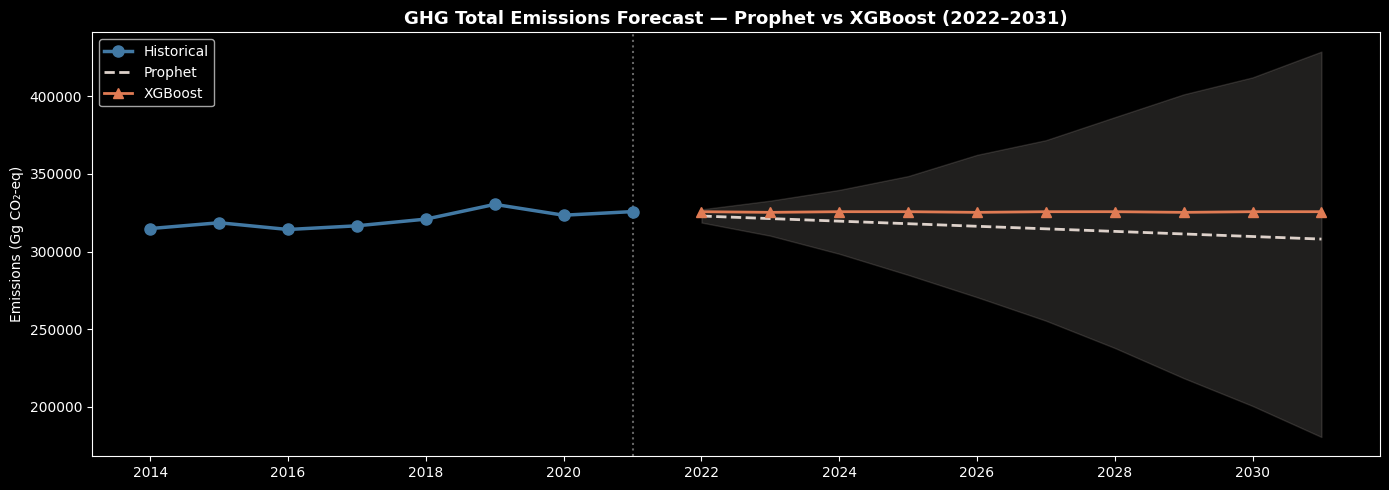

In [39]:
# ── GHG Total: Prophet vs XGBoost side-by-side ────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

# Historical observations
ax.plot(ghg_history.index, ghg_history.values, 'o-', color=ACCENT,
        linewidth=2.5, markersize=8, label='Historical', zorder=5)

# Prophet forecast
cx = forecast_prophet[forecast_prophet['ds'] > ghg_history.index.max()]
ax.plot(cx['ds'], cx['yhat'], '--', color=ACCENT2, linewidth=2, label='Prophet')
ax.fill_between(cx['ds'], cx['yhat_lower'], cx['yhat_upper'], alpha=0.15, color=ACCENT2)

# XGBoost forecast
ax.plot(xgb_years, xgb_preds, '-^', color='#e07b54', linewidth=2, markersize=7, label='XGBoost')

ax.axvline(ghg_history.index.max(), color='white', linestyle=':', alpha=0.4, lw=1.5)
ax.set_title('GHG Total Emissions Forecast — Prophet vs XGBoost (2022–2031)', fontsize=13, fontweight='bold')
ax.set_ylabel('Emissions (Gg CO₂-eq)')
ax.legend()
plt.tight_layout()
plt.show()

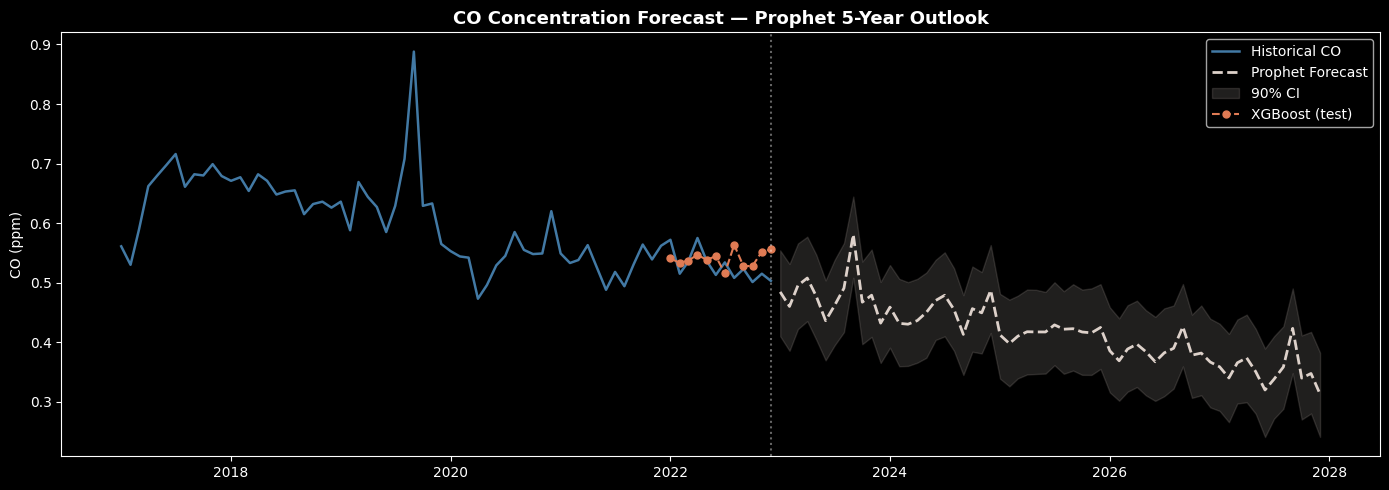

In [40]:
# ── CO Monthly: Prophet forecast with CI ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

# Historical
ax.plot(co_prophet_df['ds'], co_prophet_df['y'], color=ACCENT, linewidth=1.8, label='Historical CO')

# Forecast
co_future = forecast_co[forecast_co['ds'] > co_prophet_df['ds'].max()]
ax.plot(co_future['ds'], co_future['yhat'], '--', color=ACCENT2, linewidth=2, label='Prophet Forecast')
ax.fill_between(co_future['ds'], co_future['yhat_lower'], co_future['yhat_upper'],
                alpha=0.15, color=ACCENT2, label='90% CI')

# XGBoost test set predictions
ax.plot(test_dates_co, y_pred_co, 'o--', color='#e07b54', linewidth=1.5, markersize=5,
        label='XGBoost (test)')

ax.axvline(co_prophet_df['ds'].max(), color='white', linestyle=':', alpha=0.4, lw=1.5)
ax.set_title('CO Concentration Forecast — Prophet 5-Year Outlook', fontsize=13, fontweight='bold')
ax.set_ylabel('CO (ppm)')
ax.legend()
plt.tight_layout()
plt.show()

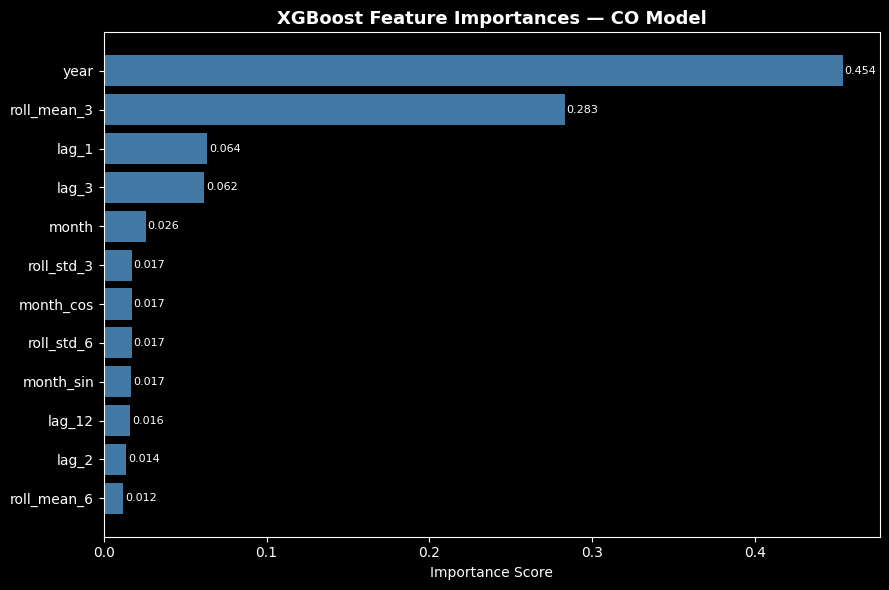

In [41]:
# ── XGBoost Feature Importance (CO model) ─────────────────────────────────────
importance = pd.Series(xgb_co.feature_importances_, index=co_feature_cols)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance.index, importance.values, color=ACCENT, edgecolor='none')
ax.set_title('XGBoost Feature Importances — CO Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

In [42]:
# ── GHG Forecast Summary Table ────────────────────────────────────────────────
prophet_futr = forecast_prophet[forecast_prophet['ds'] > ghg_history.index.max()]

summary = pd.DataFrame({
    'Year': xgb_years.year,
    'Prophet (Gg CO₂-eq)': prophet_futr['yhat'].values.round(2),
    'Prophet Lower CI': prophet_futr['yhat_lower'].values.round(2),
    'Prophet Upper CI': prophet_futr['yhat_upper'].values.round(2),
    'XGBoost (Gg CO₂-eq)': np.round(xgb_preds, 2)
})

print('\n📊 GHG Total Emission Forecast Summary (2022–2031):')
display(summary)


📊 GHG Total Emission Forecast Summary (2022–2031):


,Year,Prophet (Gg CO₂-eq),Prophet Lower CI,Prophet Upper CI,XGBoost (Gg CO₂-eq)
0,2022,322854.85,318651.34,327176.20,325646.3125
1,2023,321205.79,310167.61,332756.57,325218.0000
2,2024,319556.73,298538.38,339669.82,325646.3125
3,2025,317903.15,284921.72,348590.66,325646.3125
4,2026,316254.09,270568.51,362276.33,325218.0000
5,2027,314605.04,255429.26,371716.77,325646.3125
6,2028,312955.98,237863.01,386524.51,325646.3125
7,2029,311302.40,218390.84,401247.37,325218.0000
8,2030,309653.34,200490.21,412183.69,325646.3125
9,2031,308004.28,180497.37,428777.30,325646.3125


---
## 🏁 Summary & Key Takeaways

| Aspect | Finding |
|---|---|
| **GHG Total Trend** | Consistent upward trend from 2014–2019, slight dip in 2020 (COVID-19), recovery in 2021 |
| **Dominant Sector** | Energy accounts for ~80% of total emissions |
| **LULUCF (forests)** | Acts as a carbon sink (negative values), but shrinking |
| **Best Model (GHG)** | **Prophet** — better uncertainty quantification with very small annual dataset |
| **Best Model (Air)** | **XGBoost** — lower MAPE on test set with sufficient monthly data |
| **CO Trend** | Downward trend post-2017, with a clear dip in 2020 (lockdowns) |
| **PM10/PM2.5** | Seasonal spikes in mid-year (haze season) visible |

### Recommendations
- Acquire post-2021 GHG data for more robust modelling and train with **SARIMA** or **LSTM** when ≥15 annual points are available.
- Use air pollution forecasts as a **proxy indicator** for tracking progress toward carbon neutrality targets.
- Consider **exogenous variables** (GDP growth, energy mix, policy interventions) to improve forecast accuracy using SARIMAX or Prophet regressors.